# Part 7: Inference in Hidden Markov Models

The definitions of state space models in `dynestyx` is quite broad, and includes things like discrete-valued states. In this case, we can use the `Filter` to obtain estimates of the log-likelihood, useful for filtering afterwards.

## The Model

To show how simple the resulting parameter learning is, we will use a common example called the "occasionally dishonest casino." This is used in the [dynamax tutorials](https://probml.github.io/dynamax/notebooks/hmm/casino_hmm_inference.html), and originates from [1].

In the occasionally dishonest casino, we play a game by rolling a die. The player rolling the die is typically rolling a fair die (i.e., $p(1) = p(2) = \dots = p(6) = 1/6$), but occasionally switches to an unfair, weighted die (with $p(1) = \dots = p(5) = 1/10$ and $p(6) = 1/2$). Let us use $z$ to indicate if the weighted die is being used: $z=0$ indicates the fair die is being used, and $z=1$ indicates the weighted die is being thrown.  

The resulting HMM is specified by the probability of transitions between each state; i.e., $p(z_{t+1} = 0 | z_t = 1)$ (for which we'll use $p_{1\to 0}$ as shorthand) and $p(z_{t+1} = 1 | z_t = 0)$ (resp., $p_{0\to 1}$). For the ground truth, we will specify that 

$$ A \triangleq \begin{bmatrix} p_{0 \to 0} & p_{0 \to 1} \\ p_{1 \to 0} & p_{1 \to 1} \end{bmatrix} = \begin{bmatrix} 0.95 & 0.05 \\ 0.1 & 0.9 \end{bmatrix}. $$

In our Bayesian model, we will place a standard Dirichlet prior over the rows of $A$ and learn $p(A \,|\, y_{1:T})$ from data.

## Writing the Model in `dynestyx`

Even though this model takes on discrete states and observations, the general structure of the resulting `dynestyx` model is the same. We'll place a prior on parameters, and then define a discrete-time dynamical model.

In [1]:
import jax.numpy as jnp
import numpyro
import numpyro.distributions as dist

import dynestyx as dsx
from dynestyx import DynamicalModel, ObservationModel


class CasinoObservation(ObservationModel):
    def __call__(self, x, u, t):
        probs = jnp.array(
            [
                [1 / 6, 1 / 6, 1 / 6, 1 / 6, 1 / 6, 1 / 6],
                [1 / 10, 1 / 10, 1 / 10, 1 / 10, 1 / 10, 1 / 2],
            ]
        )
        return dist.Categorical(probs=probs[x])


def hmm_model(A=None):
    A = numpyro.sample("A", dist.Dirichlet(jnp.ones(2)).expand([2]).to_event(1), obs=A)

    def state_evolution(x, u, t_now, t_next):
        return dist.Categorical(probs=A[x])

    dynamics = DynamicalModel(
        state_dim=2,
        observation_dim=1,
        initial_condition=dist.Categorical(probs=jnp.ones(2) / 2),
        state_evolution=state_evolution,
        observation_model=CasinoObservation(),
    )

    dsx.sample("f", dynamics)

## Generating Synthetic Data

As a generic discrete-time SSM, we can generate data using the `DiscreteTimeSimulator`.

In [2]:
import jax.random as jr
from numpyro.infer import Predictive

from dynestyx import Condition, Context, DiscreteTimeSimulator, Trajectory

obs_times = jnp.arange(start=0.0, stop=10000.0, step=1.0)
context = Context(observations=Trajectory(times=obs_times))

prng_key = jr.PRNGKey(0)
predictive_model = Predictive(hmm_model, num_samples=1)

true_A = jnp.array([[0.95, 0.05], [0.1, 0.9]])

with DiscreteTimeSimulator():
    with Condition(context=context):
        synthetic_samples = predictive_model(prng_key, A=true_A)

/Users/levinema/Projects/research/dynestyx/dynestyx/dynamical_models.py:77: UserWarning: control_dim is not provided; auto-infer is not implemented yet. Setting to 0.
  warnings.warn(


We include plotting utilities to visualize the output of an HMM.

(<Figure size 1000x400 with 1 Axes>,
 <Axes: title={'center': 'HMM latent states and observations'}, xlabel='Time', ylabel='Observations'>)

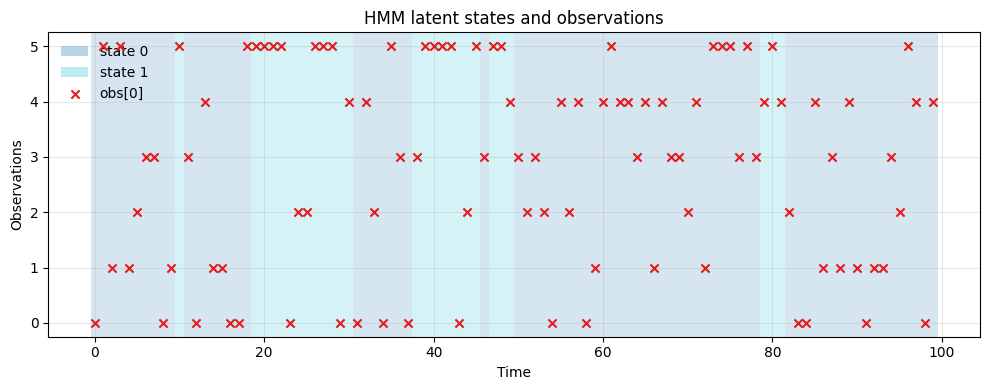

In [3]:
from dynestyx.diagnostics.plotting_utils import plot_hmm_states_and_observations

plot_hmm_states_and_observations(
    times=obs_times[:100],
    x=synthetic_samples["states"][0][:100],
    y=synthetic_samples["observations"][0][:100],
)

## Bayesian Inference on The Model

using the observations, we can now perform Bayesian inference on the model transition probabilities. For this, we can use the `dsx.filters.Filter` and, like usual, the standard `numpyro` inference toolkit.

In [4]:
from dynestyx import Filter
from dynestyx.filters import HMMConfig

# Extract observations from synthetic data
obs_values = synthetic_samples["observations"].squeeze(0)
observation_trajectory = Trajectory(times=obs_times, values=obs_values)


def data_conditioned_model():
    """
    Model conditioned on observed data, using HMMFilter for marginal likelihood.
    """
    context = Context(observations=observation_trajectory)
    with Filter(HMMConfig()):
        with Condition(context=context):
            return hmm_model()

We then can perform parameter inference using NUTS directly.

In [5]:
from numpyro.infer import MCMC, NUTS

mcmc_key = jr.PRNGKey(0)
nuts_kernel = NUTS(data_conditioned_model)
mcmc = MCMC(
    nuts_kernel,
    num_samples=500,
    num_warmup=500,
)
mcmc.run(mcmc_key)

posterior_samples = mcmc.get_samples()

sample: 100%|██████████| 1000/1000 [00:13<00:00, 72.20it/s, 7 steps of size 4.79e-01. acc. prob=0.94]


We can look at the probability of transitioning $p_{0\to 1}$ and $p_{1 \to 0}$ to analyze the uncertainty and how this matches the true generating parameter:

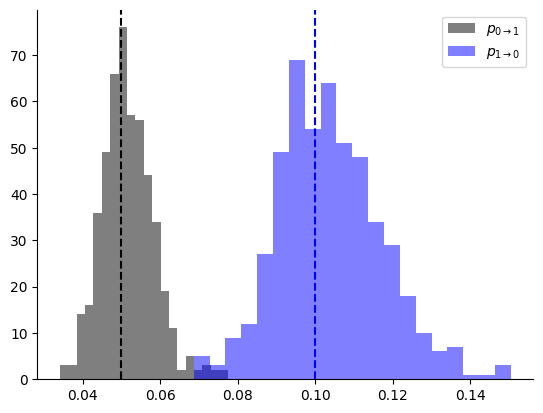

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.hist(
    posterior_samples["A"][:, 0, 1],
    bins=20,
    color="k",
    alpha=0.5,
    label=r"$p_{0\to 1}$",
)
plt.axvline(true_A[0, 1], color="k", linestyle="--")
plt.hist(
    posterior_samples["A"][:, 1, 0],
    bins=20,
    color="b",
    alpha=0.5,
    label=r"$p_{1\to 0}$",
)
plt.axvline(true_A[1, 0], color="b", linestyle="--")
sns.despine()
plt.legend()
plt.show()

## References

[1] “Biological Sequence Analysis: Probabilistic Models of Proteins and Nucleic Acids” by R. Durbin, S. Eddy, A. Krogh and G. Mitchison (1998).
